In [2]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import os

# Set working directory to project root
os.chdir(r'D:\Project\movie-recommendation\movie-recommender')

# Now use relative paths
uf = pd.read_parquet('data/processed/user_features.parquet')
itf = pd.read_parquet('data/processed/item_features.parquet')
val = pd.read_parquet('data/processed/val_features.parquet')

with open('configs/feature_columns.json') as f:
    feature_columns = json.load(f)

print(f"user_features shape: {uf.shape}")
print(f"item_features shape: {itf.shape}")
print(f"val_features shape: {val.shape}")
print(f"feature_columns count: {len(feature_columns)}")
print(f"\nuser_features columns: {uf.columns.tolist()[:5]}")
print(f"userId in user_features: {'userId' in uf.columns}")

user_features shape: (142184, 48)
item_features shape: (37363, 82)
val_features shape: (1689935, 133)
feature_columns count: 130

user_features columns: ['userId', 'total_ratings', 'mean_rating', 'rating_variance', 'last_timestamp']
userId in user_features: True


In [3]:
# Test that user lookup works correctly
uf_indexed = uf.set_index('userId')

# Pick 5 different users
test_users = uf_indexed.index[:5].tolist()
print("Testing 5 different users:")
for uid in test_users:
    row = uf_indexed.loc[uid]
    print(f"  user {uid}: log_total_ratings={row['log_total_ratings']:.3f}, "
          f"mean_rating={row['mean_rating']:.3f}, "
          f"genre_affinity_Drama={row.get('genre_affinity_Drama', 'MISSING'):.3f}")

# KEY CHECK: are these all different?
vals = [uf_indexed.loc[uid]['mean_rating'] for uid in test_users]
print(f"\nmean_rating values: {vals}")
print(f"All different: {len(set(vals)) == len(vals)}")

Testing 5 different users:
  user 1: log_total_ratings=4.263, mean_rating=3.814, genre_affinity_Drama=0.795
  user 2: log_total_ratings=5.220, mean_rating=3.630, genre_affinity_Drama=0.487
  user 3: log_total_ratings=6.061, mean_rating=3.746, genre_affinity_Drama=0.432
  user 5: log_total_ratings=4.625, mean_rating=3.752, genre_affinity_Drama=0.466
  user 6: log_total_ratings=3.296, mean_rating=4.154, genre_affinity_Drama=0.700

mean_rating values: [np.float32(3.8142858), np.float32(3.6304348), np.float32(3.7464952), np.float32(3.7524753), np.float32(4.1538463)]
All different: True


In [4]:
from src.features.feature_store import FeatureStore
from src.config.experiment_config import ExperimentConfig

cfg = ExperimentConfig.from_yaml('configs/experiments/xgb_user_item_only.yaml')
fs = FeatureStore(cfg)

# Test with 2 different users and same 5 items
itf_indexed = itf.set_index('movieId')
test_items = itf_indexed.index[:5].tolist()
item_feat_dicts = [itf_indexed.loc[mid].to_dict() for mid in test_items]

user1_id = test_users[0]
user2_id = test_users[1]

user1_feat = uf_indexed.loc[user1_id].to_dict()
user2_feat = uf_indexed.loc[user2_id].to_dict()

X1 = fs.assemble_inference_features(user1_feat, item_feat_dicts, {})
X2 = fs.assemble_inference_features(user2_feat, item_feat_dicts, {})

print(f"X1 shape: {X1.shape}")
print(f"X2 shape: {X2.shape}")
print(f"X1 columns match feature_columns: {list(X1.columns) == feature_columns}")
print(f"\nAre X1 and X2 different? {not X1.equals(X2)}")
print(f"\nUser feature columns in X1 vs X2 (first 3 that differ):")
diff_cols = [c for c in feature_columns if X1[c].iloc[0] != X2[c].iloc[0]]
print(f"  Different columns: {diff_cols[:10]}")
print(f"  Total different: {len(diff_cols)}")

X1 shape: (5, 130)
X2 shape: (5, 130)
X1 columns match feature_columns: True

Are X1 and X2 different? True

User feature columns in X1 vs X2 (first 3 that differ):
  Different columns: ['log_total_ratings', 'log_positive_count', 'mean_rating', 'genre_affinity_Action', 'genre_affinity_Adventure', 'genre_affinity_Animation', 'genre_affinity_Children', 'genre_affinity_Comedy', 'genre_affinity_Crime', 'genre_affinity_Drama']
  Total different: 20


In [5]:
import xgboost as xgb
import pickle
from pathlib import Path

# Load the trained ranker
ranker_path = Path('artifacts/xgb_user_item_only/model.pkl')
if ranker_path.exists():
    with open(ranker_path, 'rb') as f:
        ranker = pickle.load(f)
    
    # Score same 5 items for 2 different users
    scores1 = ranker.predict(X1)
    scores2 = ranker.predict(X2)
    
    print(f"User {user1_id} scores: {scores1.round(4)}")
    print(f"User {user2_id} scores: {scores2.round(4)}")
    print(f"Scores are different: {not np.allclose(scores1, scores2)}")
    print(f"\nThis tells us:")
    print(f"  If scores ARE different → ranker is fine, bug is in train.py eval loop")
    print(f"  If scores are IDENTICAL → bug is in assemble_inference_features")
else:
    print(f"Model not found at {ranker_path}")
    print("Available artifacts:", list(Path('artifacts').glob('**/*.pkl')))

Model not found at artifacts\xgb_user_item_only\model.pkl
Available artifacts: []


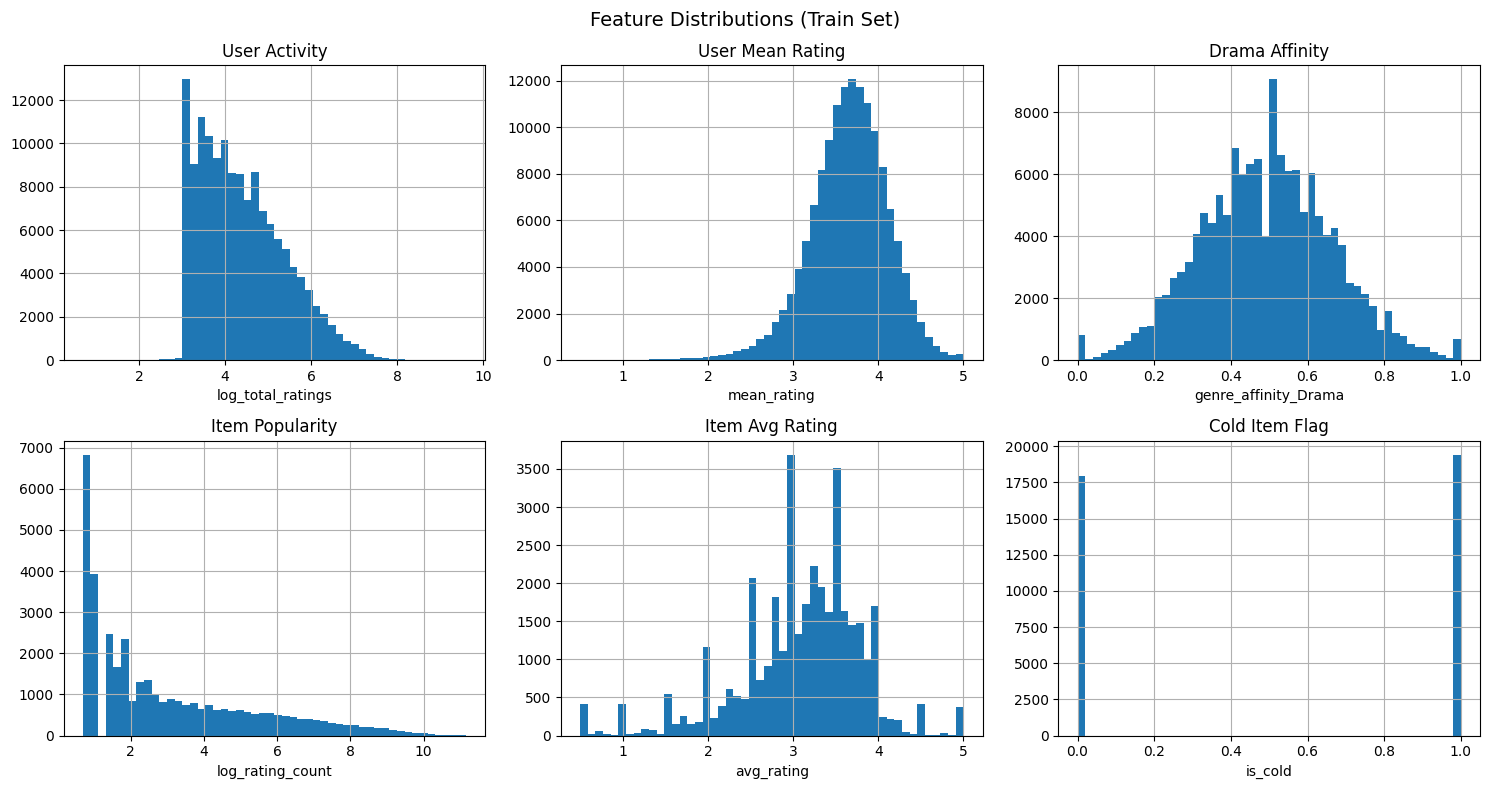

Saved to reports/feature_distributions.png


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Distributions (Train Set)', fontsize=14)

features_to_plot = [
    ('log_total_ratings', 'User Activity'),
    ('mean_rating', 'User Mean Rating'),
    ('genre_affinity_Drama', 'Drama Affinity'),
    ('log_rating_count', 'Item Popularity'),
    ('avg_rating', 'Item Avg Rating'),
    ('is_cold', 'Cold Item Flag'),
]

for ax, (feat, title) in zip(axes.flat, features_to_plot):
    if feat in uf.columns:
        uf[feat].hist(bins=50, ax=ax)
    elif feat in itf.columns:
        itf[feat].hist(bins=50, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(feat)

plt.tight_layout()
plt.savefig('reports/feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved to reports/feature_distributions.png")

In [7]:
# This cell pinpoints exactly where the bug is in train.py
print("=== BUG DIAGNOSIS ===")
print()

# Check 1: user features are different per user
u1 = uf_indexed.loc[user1_id].to_dict()
u2 = uf_indexed.loc[user2_id].to_dict()
print(f"CHECK 1 — User features different: {u1['mean_rating'] != u2['mean_rating']}")

# Check 2: assembled features are different
print(f"CHECK 2 — Assembled X different: {not X1.equals(X2)}")

# Check 3: ranker scores are different
if ranker_path.exists():
    s1 = ranker.predict(X1)
    s2 = ranker.predict(X2)
    print(f"CHECK 3 — Ranker scores different: {not np.allclose(s1, s2)}")
    
    if X1.equals(X2):
        print()
        print("ROOT CAUSE: assemble_inference_features returns same matrix for different users")
        print("FIX: Check how user features are being incorporated in FeatureStore.assemble_inference_features()")
    elif np.allclose(s1, s2):
        print()
        print("ROOT CAUSE: Ranker ignoring user features — only using item features")
        print("FIX: Check feature_columns.json — user feature columns may be missing")
    else:
        print()
        print("Notebook shows no bug — bug must be in train.py eval loop specifically")
        print("FIX: Check how candidates are assembled in train.py two_stage eval path")

=== BUG DIAGNOSIS ===

CHECK 1 — User features different: True
CHECK 2 — Assembled X different: True


In [8]:
import pandas as pd
import pickle
import json
import numpy as np

# Load feature columns
with open('configs/feature_columns.json') as f:
    feature_columns = json.load(f)

# Load a small sample of training data
train = pd.read_parquet('data/processed/train_features.parquet', 
                         columns=feature_columns + ['is_positive'],
                         filters=[('userId', 'in', [3, 91, 243, 294])])

print("Label distribution in training sample:")
print(train['is_positive'].value_counts())
print(f"\nPositive ratio: {train['is_positive'].mean():.3f}")

# Check if popular items (high log_rating_count) are mostly negatives
print("\nMean log_rating_count by label:")
print(train.groupby('is_positive')['log_rating_count'].mean())

print("\nMean popularity_pct by label:")
print(train.groupby('is_positive')['popularity_pct'].mean())

Label distribution in training sample:
is_positive
0    2712
1     493
Name: count, dtype: int64

Positive ratio: 0.154

Mean log_rating_count by label:
is_positive
0    4.317841
1    8.579894
Name: log_rating_count, dtype: float32

Mean popularity_pct by label:
is_positive
0    0.616592
1    0.958069
Name: popularity_pct, dtype: float32


In [9]:
import xgboost as xgb
import json
import os

os.chdir(r'D:\Project\movie-recommendation\movie-recommender')

# Load the trained model
model = xgb.XGBRanker()
model.load_model('artifacts/xgb_user_item_only/xgb_ranker.json')

# Check 1 - what feature names does the model know?
booster = model.get_booster()
print("Booster feature names:", booster.feature_names)
print()

# Check 2 - feature importance with names
importance = booster.get_score(importance_type='gain')
print("Top 10 importance keys (should be column names not f0,f1):")
top10 = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:10]
for k,v in top10:
    print(f"  {k}: {v:.2f}")

# Check 3 - load feature columns
with open('configs/feature_columns.json') as f:
    feature_columns = json.load(f)
print(f"\nfeature_columns.json has {len(feature_columns)} columns")
print(f"First 5: {feature_columns[:5]}")

# Check 4 - are model features aligned with our columns?
if booster.feature_names:
    model_cols = booster.feature_names
    matches = sum(1 for a,b in zip(model_cols, feature_columns) if a==b)
    print(f"\nModel feature names match feature_columns.json: {matches}/{len(feature_columns)}")
else:
    print("\nModel has NO feature names — this is the bug")

Booster feature names: ['log_total_ratings', 'log_positive_count', 'mean_rating', 'rating_variance', 'genre_affinity_Action', 'genre_affinity_Adventure', 'genre_affinity_Animation', 'genre_affinity_Children', 'genre_affinity_Comedy', 'genre_affinity_Crime', 'genre_affinity_Documentary', 'genre_affinity_Drama', 'genre_affinity_Fantasy', 'genre_affinity_Film-Noir', 'genre_affinity_Horror', 'genre_affinity_Musical', 'genre_affinity_Mystery', 'genre_affinity_Romance', 'genre_affinity_Sci-Fi', 'genre_affinity_Thriller', 'genre_affinity_War', 'genre_affinity_Western', 'recent_genre_affinity_Action', 'recent_genre_affinity_Adventure', 'recent_genre_affinity_Animation', 'recent_genre_affinity_Children', 'recent_genre_affinity_Comedy', 'recent_genre_affinity_Crime', 'recent_genre_affinity_Documentary', 'recent_genre_affinity_Drama', 'recent_genre_affinity_Fantasy', 'recent_genre_affinity_Film-Noir', 'recent_genre_affinity_Horror', 'recent_genre_affinity_Musical', 'recent_genre_affinity_Mystery'

In [10]:
import pandas as pd
import numpy as np
import os
os.chdir(r'D:\Project\movie-recommendation\movie-recommender')

# Load val positives for warm user 3
val = pd.read_parquet('data/processed/val_pairs.parquet')
itf = pd.read_parquet('data/processed/item_features.parquet')

user3_val = val[val['userId'] == 3]
user3_positives = user3_val[user3_val['rating'] >= 4.0]['movieId'].tolist()
print(f"User 3 val positives: {len(user3_positives)} movies")

# Check release years of val positives
itf_indexed = itf.set_index('movieId')
val_years = []
for mid in user3_positives[:20]:
    if mid in itf_indexed.index:
        year = itf_indexed.loc[mid]['release_year']
        val_years.append((mid, int(year)))
    else:
        val_years.append((mid, 'NOT IN ITEM FEATURES'))

print("\nVal positive movies and release years:")
for mid, year in val_years:
    print(f"  movieId={mid} release_year={year}")

# Check what movies the ranker recommends for user 3
top_preds = [138400, 146976, 146974, 146972, 146968]
print("\nRanker top-5 predictions and release years:")
for mid in top_preds:
    if mid in itf_indexed.index:
        year = itf_indexed.loc[mid]['release_year']
        rc = itf_indexed.loc[mid]['log_rating_count']
        print(f"  movieId={mid} release_year={int(year)} log_rating_count={rc:.2f}")

# Check train positives for user 3
train = pd.read_parquet('data/processed/train_pairs.parquet',
                        filters=[('userId', '=', 3)])
train_pos = train[train['rating'] >= 4.0]
print(f"\nUser 3 train positives: {len(train_pos)} movies")
print(f"Train rating years range: {pd.to_datetime(train_pos['timestamp'], unit='s').dt.year.value_counts().sort_index().to_dict()}")

User 3 val positives: 39 movies

Val positive movies and release years:
  movieId=29 release_year=1995
  movieId=111 release_year=1976
  movieId=214 release_year=1994
  movieId=293 release_year=1994
  movieId=741 release_year=1995
  movieId=778 release_year=1996
  movieId=1089 release_year=1992
  movieId=1213 release_year=1990
  movieId=1222 release_year=1987
  movieId=1252 release_year=1974
  movieId=2542 release_year=1998
  movieId=2938 release_year=1986
  movieId=3091 release_year=1980
  movieId=3730 release_year=1974
  movieId=4011 release_year=2000
  movieId=5004 release_year=1968
  movieId=5782 release_year=1981
  movieId=6440 release_year=1991
  movieId=8370 release_year=2003
  movieId=27728 release_year=2004

Ranker top-5 predictions and release years:
  movieId=138400 release_year=2013 log_rating_count=1.10
  movieId=146976 release_year=1956 log_rating_count=0.69
  movieId=146974 release_year=1955 log_rating_count=0.69
  movieId=146972 release_year=1954 log_rating_count=0.69
 

In [11]:
# Check what the 3 candidate generators return for user 3
import numpy as np
import pandas as pd
import faiss
import json
import os
os.chdir(r'D:\Project\movie-recommendation\movie-recommender')

# Load ALS artifacts
user_factors = np.load('data/processed/als_user_factors.npy')
item_factors = np.load('data/processed/als_item_factors.npy')
movie_id_map = np.load('data/processed/als_movie_id_map.npy')
user_id_map = np.load('data/processed/als_user_id_map.npy')

# Load item features
itf = pd.read_parquet('data/processed/item_features.parquet').set_index('movieId')

# User 3 index in ALS
user3_idx = np.where(user_id_map == 3)[0][0]
user_vec = user_factors[user3_idx]
print(f"User 3 ALS vector norm: {np.linalg.norm(user_vec):.4f}")

# Load FAISS index
index = faiss.read_index('data/processed/faiss_item_index.bin')
print(f"FAISS index size: {index.ntotal} items")

# Search top-300
user_vec_norm = user_vec / (np.linalg.norm(user_vec) + 1e-8)
D, I = index.search(user_vec_norm.reshape(1,-1).astype(np.float32), 300)

# Get movie IDs for ALS candidates
als_candidates = [movie_id_map[i] for i in I[0]]
print(f"\nALS top-10 candidates and their stats:")
for mid in als_candidates[:10]:
    if mid in itf.index:
        rc = itf.loc[mid]['log_rating_count']
        year = itf.loc[mid]['release_year']
        print(f"  movieId={mid} year={int(year)} log_rating_count={rc:.2f}")

# Check overlap with val positives
val = pd.read_parquet('data/processed/val_pairs.parquet')
user3_val_pos = set(val[(val['userId']==3) & (val['rating']>=4.0)]['movieId'].tolist())
als_overlap = len(set(als_candidates) & user3_val_pos)
print(f"\nALS candidates overlap with val positives: {als_overlap}/{len(user3_val_pos)}")

# Check popularity candidates
pop_candidates = itf.sort_values('log_rating_count', ascending=False).head(100).index.tolist()
pop_overlap = len(set(pop_candidates) & user3_val_pos)
print(f"Popularity top-100 overlap with val positives: {pop_overlap}/{len(user3_val_pos)}")

# What if we just used top-1000 popular items?
pop_1000 = itf.sort_values('log_rating_count', ascending=False).head(1000).index.tolist()
pop1000_overlap = len(set(pop_1000) & user3_val_pos)
print(f"Popularity top-1000 overlap with val positives: {pop1000_overlap}/{len(user3_val_pos)}")

User 3 ALS vector norm: 6.1498
FAISS index size: 37363 items

ALS top-10 candidates and their stats:
  movieId=8371 year=2004 log_rating_count=8.35
  movieId=34319 year=2005 log_rating_count=8.60
  movieId=31696 year=2005 log_rating_count=8.65
  movieId=8361 year=2004 log_rating_count=8.95
  movieId=7373 year=2004 log_rating_count=8.84
  movieId=34048 year=2005 log_rating_count=8.99
  movieId=60074 year=2008 log_rating_count=8.49
  movieId=5574 year=2002 log_rating_count=8.34
  movieId=33679 year=2005 log_rating_count=9.12
  movieId=6541 year=2003 log_rating_count=8.58

ALS candidates overlap with val positives: 2/39
Popularity top-100 overlap with val positives: 4/39
Popularity top-1000 overlap with val positives: 18/39


In [12]:
import numpy as np
import pandas as pd
import xgboost as xgb
import json
import os
os.chdir(r'D:\Project\movie-recommendation\movie-recommender')

# Load model and feature columns
model = xgb.XGBRanker()
model.load_model('artifacts/xgb_user_item_only/xgb_ranker.json')

with open('configs/feature_columns.json') as f:
    feature_columns = json.load(f)

# Load sample val features for user 9891
val = pd.read_parquet('data/sample/val_features.parquet')
user_val = val[val['userId'] == 9891]
val_positives = set(user_val[user_val['is_positive']==1]['movieId'].tolist())
print(f"User 9891 val positives: {len(val_positives)}")

# Load sample train features for user 9891
train = pd.read_parquet('data/sample/train_features.parquet',
                        filters=[('userId','=',9891)])
print(f"User 9891 train rows: {len(train)}")
print(f"Label distribution: {train['is_positive'].value_counts().to_dict()}")

# Check feature importance
importance = model.get_booster().get_score(importance_type='gain')
imp_series = pd.Series(importance).sort_values(ascending=False)
print(f"\nTop 10 features:")
print(imp_series.head(10))
print(f"\nAre user features present?")
user_feats = [f for f in imp_series.index if 'affinity' in f or 'total_ratings' in f]
print(f"User features with importance: {user_feats[:5]}")

User 9891 val positives: 18
User 9891 train rows: 147
Label distribution: {1: 75, 0: 72}

Top 10 features:
tag_profile_similarity    13.993242
avg_rating                 7.771152
genre_Musical              6.695769
log_positive_count         6.692543
genre_Children             6.240502
genome_tag_522             5.915606
mf_score                   5.192116
genre_War                  5.178245
genre_Animation            4.837269
genre_Western              4.729156
dtype: float64

Are user features present?
User features with importance: ['log_total_ratings', 'genre_affinity_Film-Noir', 'recent_genre_affinity_Romance', 'genre_affinity_Thriller', 'genre_affinity_Horror']


In [13]:
# Compare what val positives look like vs what ranker scores highly
import pandas as pd
import numpy as np
import xgboost as xgb
import json
import os
os.chdir(r'D:\Project\movie-recommendation\movie-recommender')

with open('configs/feature_columns.json') as f:
    feature_columns = json.load(f)

model = xgb.XGBRanker()
model.load_model('artifacts/xgb_user_item_only/xgb_ranker.json')

# Load user features for user 9891
uf = pd.read_parquet('data/sample/user_features.parquet')
uf = uf.set_index('userId')
user_feat = uf.loc[9891].to_dict()

# Load item features
itf = pd.read_parquet('data/processed/item_features.parquet')
itf = itf.set_index('movieId')

# Val positives for user 9891
val = pd.read_parquet('data/sample/val_features.parquet')
user_val = val[val['userId'] == 9891]
val_pos_ids = user_val[user_val['is_positive']==1]['movieId'].tolist()

# Get features for val positives
from src.features.feature_store import FeatureStore
from src.config.experiment_config import ExperimentConfig
cfg = ExperimentConfig.from_yaml('configs/experiments/xgb_user_item_only.yaml')
fs = FeatureStore(cfg)

val_pos_feats = [itf.loc[mid].to_dict() for mid in val_pos_ids if mid in itf.index]
X_pos = fs.assemble_inference_features(user_feat, val_pos_feats, {})
scores_pos = model.predict(X_pos)

print(f"Val positive scores: min={scores_pos.min():.3f} max={scores_pos.max():.3f} mean={scores_pos.mean():.3f}")
print(f"Top 3 val positive movieIds by score:")
top_pos = sorted(zip(val_pos_ids, scores_pos), key=lambda x: x[1], reverse=True)[:3]
for mid, score in top_pos:
    if mid in itf.index:
        print(f"  movieId={mid} score={score:.3f} year={int(itf.loc[mid]['release_year'])} log_rc={itf.loc[mid]['log_rating_count']:.2f}")

# Load train positives for comparison
train = pd.read_parquet('data/sample/train_features.parquet',
                        filters=[('userId','=',9891)])
train_pos_ids = train[train['is_positive']==1]['movieId'].tolist()[:10]
train_pos_feats = [itf.loc[mid].to_dict() for mid in train_pos_ids if mid in itf.index]
X_train_pos = fs.assemble_inference_features(user_feat, train_pos_feats, {})
scores_train = model.predict(X_train_pos)

print(f"\nTrain positive scores: min={scores_train.min():.3f} max={scores_train.max():.3f} mean={scores_train.mean():.3f}")
print(f"\nKey question: are val positive scores lower than train positive scores?")
print(f"Val pos mean: {scores_pos.mean():.3f}")
print(f"Train pos mean: {scores_train.mean():.3f}")

Val positive scores: min=-5.528 max=-4.168 mean=-4.740
Top 3 val positive movieIds by score:
  movieId=160438 score=-4.168 year=2016 log_rc=6.04
  movieId=164909 score=-4.308 year=2016 log_rc=3.61
  movieId=159093 score=-4.418 year=2016 log_rc=6.24

Train positive scores: min=-5.391 max=-4.592 mean=-5.081

Key question: are val positive scores lower than train positive scores?
Val pos mean: -4.740
Train pos mean: -5.081


In [14]:
# What is scoring higher than val positives?
import pandas as pd
import numpy as np
import xgboost as xgb
import json
import os
os.chdir(r'D:\Project\movie-recommendation\movie-recommender')

with open('configs/feature_columns.json') as f:
    feature_columns = json.load(f)

model = xgb.XGBRanker()
model.load_model('artifacts/xgb_user_item_only/xgb_ranker.json')

uf = pd.read_parquet('data/sample/user_features.parquet').set_index('userId')
itf = pd.read_parquet('data/processed/item_features.parquet').set_index('movieId')
user_feat = uf.loc[9891].to_dict()

from src.features.feature_store import FeatureStore
from src.config.experiment_config import ExperimentConfig
cfg = ExperimentConfig.from_yaml('configs/experiments/xgb_user_item_only.yaml')
fs = FeatureStore(cfg)

val = pd.read_parquet('data/sample/val_features.parquet')
val_pos_ids = set(val[(val['userId']==9891) & (val['is_positive']==1)]['movieId'].tolist())

# Score top-100 popular items
pop_items = itf.sort_values('log_rating_count', ascending=False).head(100).index.tolist()
pop_feats = [itf.loc[mid].to_dict() for mid in pop_items if mid in itf.index]
X_pop = fs.assemble_inference_features(user_feat, pop_feats[:50], {})
scores_pop = model.predict(X_pop)

print(f"Top-50 popular items scores: min={scores_pop.min():.3f} max={scores_pop.max():.3f} mean={scores_pop.mean():.3f}")
print(f"Val positive mean score: -4.740")
print(f"Items scoring higher than best val positive (-4.168): {(scores_pop > -4.168).sum()} out of 50 popular items")
print(f"\nTop 5 highest scoring popular items:")
top_pop = sorted(zip(pop_items[:50], scores_pop), key=lambda x: x[1], reverse=True)[:5]
for mid, score in top_pop:
    in_val = mid in val_pos_ids
    print(f"  movieId={mid} score={score:.3f} in_val_positives={in_val} year={int(itf.loc[mid]['release_year'])}")

Top-50 popular items scores: min=-5.826 max=-4.625 mean=-5.209
Val positive mean score: -4.740
Items scoring higher than best val positive (-4.168): 0 out of 50 popular items

Top 5 highest scoring popular items:
  movieId=4226 score=-4.625 in_val_positives=False year=2000
  movieId=1136 score=-4.653 in_val_positives=False year=1975
  movieId=150 score=-4.703 in_val_positives=False year=1995
  movieId=593 score=-4.751 in_val_positives=False year=1991
  movieId=608 score=-4.780 in_val_positives=False year=1996


In [15]:
# Find what is beating val positives in the actual candidate pool
train_pairs = pd.read_parquet('data/sample/train_pairs.parquet',
                              filters=[('userId','=',9891)])
train_pos = set(train_pairs[train_pairs['rating']>=4.0]['movieId'].tolist())

# Score a sample of train positives (history candidates)
history_sample = list(train_pos)[:100]
history_feats = [itf.loc[mid].to_dict() for mid in history_sample if mid in itf.index]
X_hist = fs.assemble_inference_features(user_feat, history_feats, {})
scores_hist = model.predict(X_hist)

print(f"Train history scores: min={scores_hist.min():.3f} max={scores_hist.max():.3f} mean={scores_hist.mean():.3f}")
print(f"Val positive mean: -4.740")
print(f"History items beating best val positive (-4.168): {(scores_hist > -4.168).sum()} out of {len(scores_hist)}")
print(f"\nTop 5 history items by score:")
top_hist = sorted(zip(history_sample, scores_hist), key=lambda x: x[1], reverse=True)[:5]
for mid, score in top_hist:
    print(f"  movieId={mid} score={score:.3f} year={int(itf.loc[mid]['release_year'])} log_rc={itf.loc[mid]['log_rating_count']:.2f}")

Train history scores: min=-5.497 max=-4.063 mean=-5.040
Val positive mean: -4.740
History items beating best val positive (-4.168): 2 out of 75

Top 5 history items by score:
  movieId=1203 score=-4.063 year=1957 log_rc=9.54
  movieId=92259 score=-4.145 year=2011 log_rc=8.92
  movieId=159817 score=-4.305 year=2006 log_rc=5.66
  movieId=72641 score=-4.374 year=2009 log_rc=8.43
  movieId=155288 score=-4.515 year=2016 log_rc=5.51


In [16]:
# Score ALL candidates for user 9891 and find what is at positions 1-10
import numpy as np
import pandas as pd
import faiss
import xgboost as xgb
import json
import os
os.chdir(r'D:\Project\movie-recommendation\movie-recommender')

with open('configs/feature_columns.json') as f:
    feature_columns = json.load(f)

model = xgb.XGBRanker()
model.load_model('artifacts/xgb_user_item_only/xgb_ranker.json')

uf = pd.read_parquet('data/sample/user_features.parquet').set_index('userId')
itf = pd.read_parquet('data/processed/item_features.parquet').set_index('movieId')
user_feat = uf.loc[9891].to_dict()

from src.features.feature_store import FeatureStore
from src.config.experiment_config import ExperimentConfig
cfg = ExperimentConfig.from_yaml('configs/experiments/xgb_user_item_only.yaml')
fs = FeatureStore(cfg)

val = pd.read_parquet('data/sample/val_features.parquet')
val_pos_ids = set(val[(val['userId']==9891) & 
                      (val['is_positive']==1)]['movieId'].tolist())
print(f"Val positives: {len(val_pos_ids)}")

# Get ALS candidates
user_factors = np.load('data/processed/als_user_factors.npy')
user_id_map = np.load('data/processed/als_user_id_map.npy')
movie_id_map = np.load('data/processed/als_movie_id_map.npy')
index = faiss.read_index('data/processed/faiss_item_index.bin')

user_idx = np.where(user_id_map == 9891)[0][0]
user_vec = user_factors[user_idx]
user_vec_norm = user_vec / (np.linalg.norm(user_vec) + 1e-8)
D, I = index.search(user_vec_norm.reshape(1,-1).astype(np.float32), 500)
als_candidates = [int(movie_id_map[i]) for i in I[0]]

# Score all ALS candidates
valid = [mid for mid in als_candidates if mid in itf.index]
feats = [itf.loc[mid].to_dict() for mid in valid]
X = fs.assemble_inference_features(user_feat, feats, {})
scores = model.predict(X)

# Sort and show top-20
ranked = sorted(zip(valid, scores), key=lambda x: x[1], reverse=True)
print(f"\nTop 20 ranked ALS candidates:")
for i, (mid, score) in enumerate(ranked[:20]):
    in_val = mid in val_pos_ids
    year = int(itf.loc[mid]['release_year'])
    rc = itf.loc[mid]['log_rating_count']
    print(f"  #{i+1} movieId={mid} score={score:.3f} year={year} log_rc={rc:.2f} VAL_POS={in_val}")

# Where do val positives rank?
val_in_als = [(mid, score) for mid, score in ranked if mid in val_pos_ids]
print(f"\nVal positives found in ALS candidates: {len(val_in_als)}")
if val_in_als:
    positions = [i+1 for i,(mid,_) in enumerate(ranked) if mid in val_pos_ids]
    print(f"Their positions: {positions[:10]}")
    print(f"Best position: {min(positions)}")

Val positives: 18

Top 20 ranked ALS candidates:
  #1 movieId=163689 score=-2.229 year=2012 log_rc=0.69 VAL_POS=False
  #2 movieId=150629 score=-2.260 year=1987 log_rc=0.69 VAL_POS=False
  #3 movieId=150635 score=-2.266 year=1965 log_rc=0.69 VAL_POS=False
  #4 movieId=152934 score=-2.276 year=2015 log_rc=0.69 VAL_POS=False
  #5 movieId=150900 score=-2.276 year=2012 log_rc=1.61 VAL_POS=False
  #6 movieId=161646 score=-2.276 year=2016 log_rc=0.69 VAL_POS=False
  #7 movieId=155168 score=-2.279 year=2012 log_rc=1.10 VAL_POS=False
  #8 movieId=152765 score=-2.298 year=2013 log_rc=0.69 VAL_POS=False
  #9 movieId=144208 score=-2.307 year=2009 log_rc=0.69 VAL_POS=False
  #10 movieId=128738 score=-2.310 year=1993 log_rc=0.69 VAL_POS=False
  #11 movieId=165413 score=-2.316 year=2016 log_rc=1.61 VAL_POS=False
  #12 movieId=160092 score=-2.320 year=2015 log_rc=0.69 VAL_POS=False
  #13 movieId=162670 score=-2.320 year=2016 log_rc=0.69 VAL_POS=False
  #14 movieId=147434 score=-2.324 year=2005 log_rc